# 02a — Approximating KL Divergence

> *A beginner's walk through John Schulman's
> [Approximating KL Divergence](http://joschu.net/blog/kl-approx.html) (2020), with every
> claim recomputed.*

## What the post is about, in one paragraph

You want to know how different two probability distributions $p$ and $q$ are. The standard
measure is **KL divergence**. Often you cannot compute it exactly — you can only draw samples
and evaluate log-probabilities. So you estimate it.

The obvious estimator works but is **noisy**. Schulman's post presents a better one that is
still **exactly correct on average** but much **quieter**:

$$\boxed{\;k_3 = (r - 1) - \log r\;} \qquad \text{where } r = \frac{p(x)}{q(x)}, \quad x \sim q$$

That is the whole punchline. This notebook explains every symbol in it, why the obvious
choice is worse, and reproduces the post's numbers.

## The three estimators

All use samples $x \sim q$ and the ratio $r = p(x)/q(x)$:

| | formula | unbiased? | variance |
|---|---|---|---|
| $k_1$ | $-\log r$ | **yes** | **high** |
| $k_2$ | $\tfrac12 (\log r)^2$ | no (but tiny bias) | low |
| $k_3$ | $(r-1) - \log r$ | **yes** | **low** |

$k_3$ is unbiased *and* low variance, so it dominates. The interesting question is how you
would ever think of it — that is §7–8, and the answer is **control variates**.

## Route

| § | |
|---|---|
| 1 | What KL divergence actually measures |
| 2 | Why you would ever need to *estimate* it |
| 3 | $k_1$: the obvious estimator, and why it is noisy |
| 4 | Bias and variance, for beginners |
| 5 | $k_2$: low variance, small bias |
| 6 | Why $k_2$ works — $f$-divergences agree to second order |
| 7 | Control variates — the trick that fixes $k_1$ |
| 8 | $k_3$: unbiased *and* low variance |
| 9 | The Bregman-divergence picture |
| 10 | Reproducing the post's experiments |
| 11 | The *other* KL divergence |
| 12 | The convention trap (worth reading) |
| 13 | Where this is used: PPO and RLHF |

**Prerequisite:** notebook 02 covers entropy and KL from scratch. No PyTorch needed here —
the original used it, we use numpy/scipy so it runs anywhere.

---
## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.integrate import quad

plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'font.size': 11, 'figure.dpi': 100})
sns.set_style("whitegrid")
np.set_printoptions(precision=6, suppress=True)
rng = np.random.default_rng(0)
print(f"numpy {np.__version__}")

numpy 2.2.6


---
## 1. What KL divergence measures

$\mathrm{KL}[q, p]$ answers: *"if the truth is $q$ but I model it with $p$, how much am I
losing?"* It is written

$$\mathrm{KL}[q,p] \;=\; \sum_x q(x)\log\frac{q(x)}{p(x)} \;=\; \mathbb{E}_{x\sim q}\!\left[\log\frac{q(x)}{p(x)}\right]$$

Three facts to carry:

1. **It is an average over $q$** — the first argument. You draw samples from $q$.
2. **It is always $\ge 0$**, and $=0$ only when $p = q$.
3. **It is not symmetric**: $\mathrm{KL}[q,p] \ne \mathrm{KL}[p,q]$ in general. So it is not a
   distance, and the order of the arguments matters enormously (see §11, §12).

### 1.1 The simplest possible example: two coins

Before any calculus, do it on a coin, where the "sum over $x$" is two terms you can add up by
hand.

- $q$ = a **fair** coin: $q(\text{H}) = 0.5$, $q(\text{T}) = 0.5$
- $p$ = a **biased** coin: $p(\text{H}) = 0.9$, $p(\text{T}) = 0.1$

$$\mathrm{KL}[q,p] = \underbrace{0.5\log\tfrac{0.5}{0.9}}_{\text{heads}}
 + \underbrace{0.5\log\tfrac{0.5}{0.1}}_{\text{tails}}
 = 0.5(-0.5878) + 0.5(1.6094) = 0.5108$$

Notice the heads term is **negative** and the tails term is positive, and they do not cancel —
the total comes out positive. That tug-of-war is the whole reason $k_1$ is noisy.

In [2]:
def kl_discrete(q, p):
    q, p = np.asarray(q, float), np.asarray(p, float)
    return float(np.sum(q * np.log(q / p)))

q_coin = [0.5, 0.5]          # fair
p_coin = [0.9, 0.1]          # biased

print("outcome-by-outcome contributions to KL[q,p]:\n")
print(f"{'outcome':>9}{'q(x)':>8}{'p(x)':>8}{'log(q/p)':>12}{'q * log(q/p)':>16}")
print("-" * 55)
total = 0.0
for name, qi, pi in zip(["heads", "tails"], q_coin, p_coin):
    term = qi * np.log(qi/pi)
    total += term
    print(f"{name:>9}{qi:>8.2f}{pi:>8.2f}{np.log(qi/pi):>12.4f}{term:>16.4f}")
print("-" * 55)
print(f"{'KL[q,p]':>44}{total:>11.4f}")
print(f"\ncheck with the helper: {kl_discrete(q_coin, p_coin):.4f}")

print(f"\nand the other direction is DIFFERENT:")
print(f"   KL[q,p] (fair vs biased) = {kl_discrete(q_coin, p_coin):.4f}")
print(f"   KL[p,q] (biased vs fair) = {kl_discrete(p_coin, q_coin):.4f}")
print("\nKL is not a distance. Which one you want depends on the question you asked.")

print(f"\nand KL is 0 exactly when the two agree:")
print(f"   KL[fair, fair] = {kl_discrete(q_coin, q_coin):.4f}")

outcome-by-outcome contributions to KL[q,p]:

  outcome    q(x)    p(x)    log(q/p)    q * log(q/p)
-------------------------------------------------------
    heads    0.50    0.90     -0.5878         -0.2939
    tails    0.50    0.10      1.6094          0.8047
-------------------------------------------------------
                                     KL[q,p]     0.5108

check with the helper: 0.5108

and the other direction is DIFFERENT:
   KL[q,p] (fair vs biased) = 0.5108
   KL[p,q] (biased vs fair) = 0.3681

KL is not a distance. Which one you want depends on the question you asked.

and KL is 0 exactly when the two agree:
   KL[fair, fair] = 0.0000


For two Gaussians there is a closed form, which is what lets us check everything numerically
later:

$$\mathrm{KL}\big[\mathcal{N}(\mu_1,\sigma_1^2)\,,\,\mathcal{N}(\mu_2,\sigma_2^2)\big]
= \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2} - \frac12$$

In [3]:
def kl_gauss(mu1, s1, mu2, s2):
    # KL[ N(mu1,s1^2) || N(mu2,s2^2) ]  -- average taken over the FIRST distribution
    return np.log(s2/s1) + (s1**2 + (mu1-mu2)**2) / (2*s2**2) - 0.5

# sanity check the closed form against brute-force numerical integration
def kl_numeric(mu1, s1, mu2, s2):
    f = lambda x: stats.norm.pdf(x, mu1, s1) * (
        stats.norm.logpdf(x, mu1, s1) - stats.norm.logpdf(x, mu2, s2))
    return quad(f, mu1 - 12*s1, mu1 + 12*s1, limit=400)[0]

print(f"{'KL[ N(m1,s1) || N(m2,s2) ]':<34}{'closed form':>14}{'numerical':>14}{'diff':>12}")
print("-" * 76)
for (m1,s1,m2,s2) in [(0,1, 0,1), (0,1, 0.1,1), (0,1, 1,1), (0,1, 0,2), (0,2, 0,1)]:
    a, b = kl_gauss(m1,s1,m2,s2), kl_numeric(m1,s1,m2,s2)
    print(f"{f'N({m1},{s1}) || N({m2},{s2})':<34}{a:>14.8f}{b:>14.8f}{abs(a-b):>12.1e}")

print("\nNote row 1: identical distributions -> KL = 0 exactly.")
print("Note rows 4 and 5: swapping the arguments changes the answer.")
print(f"   KL[N(0,1)||N(0,2)] = {kl_gauss(0,1,0,2):.6f}")
print(f"   KL[N(0,2)||N(0,1)] = {kl_gauss(0,2,0,1):.6f}   <- NOT symmetric")

KL[ N(m1,s1) || N(m2,s2) ]           closed form     numerical        diff
----------------------------------------------------------------------------
N(0,1) || N(0,1)                      0.00000000    0.00000000     0.0e+00
N(0,1) || N(0.1,1)                    0.00500000    0.00500000     9.5e-18
N(0,1) || N(1,1)                      0.50000000    0.50000000     2.2e-16
N(0,1) || N(0,2)                      0.31814718    0.31814718     0.0e+00
N(0,2) || N(0,1)                      0.80685282    0.80685282     2.2e-16

Note row 1: identical distributions -> KL = 0 exactly.
Note rows 4 and 5: swapping the arguments changes the answer.
   KL[N(0,1)||N(0,2)] = 0.318147
   KL[N(0,2)||N(0,1)] = 0.806853   <- NOT symmetric


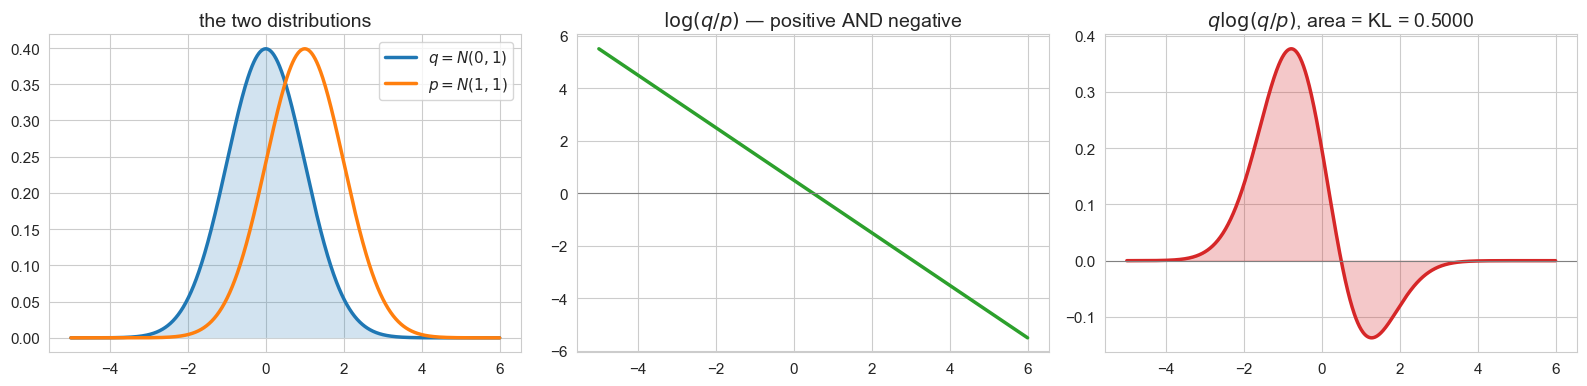

The middle panel is the key to the whole post: log(q/p) is NEGATIVE over a large
region. KL is the q-weighted average, which comes out positive -- but any single
sample of log(q/p) can easily be negative. That is where the variance comes from.


In [4]:
# What KL "sees": the q-weighted log-ratio.
xs = np.linspace(-5, 6, 1000)
q_pdf = stats.norm.pdf(xs, 0, 1)
p_pdf = stats.norm.pdf(xs, 1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(xs, q_pdf, lw=2.5, label='$q = N(0,1)$')
axes[0].plot(xs, p_pdf, lw=2.5, label='$p = N(1,1)$')
axes[0].fill_between(xs, q_pdf, alpha=.2); axes[0].legend(); axes[0].set_title("the two distributions")

logratio = stats.norm.logpdf(xs,0,1) - stats.norm.logpdf(xs,1,1)
axes[1].plot(xs, logratio, lw=2.5, color='C2')
axes[1].axhline(0, color='grey', lw=.8)
axes[1].set_title("$\\log(q/p)$ — positive AND negative")

integrand = q_pdf * logratio
axes[2].plot(xs, integrand, lw=2.5, color='C3')
axes[2].fill_between(xs, integrand, alpha=.25, color='C3')
axes[2].axhline(0, color='grey', lw=.8)
axes[2].set_title(f"$q\\log(q/p)$, area = KL = {kl_gauss(0,1,1,1):.4f}")
plt.tight_layout(); plt.show()

print("The middle panel is the key to the whole post: log(q/p) is NEGATIVE over a large")
print("region. KL is the q-weighted average, which comes out positive -- but any single")
print("sample of log(q/p) can easily be negative. That is where the variance comes from.")

---
## 2. Why estimate KL at all?

If there is a closed form, use it. The post lists three reasons you often cannot:

1. **Too expensive.** The sum over $x$ is over a huge space — e.g. every token in a
   vocabulary, at every position, for every sequence.
2. **No closed form.** The distributions are not a convenient family.
3. **You only stored the log-probs.** Very common in reinforcement learning: the rollout
   saved $\log q(x)$ for the action it took, not the whole distribution. KL is being used as
   a *diagnostic*, so this keeps the code simple.

So the setting is: **you can evaluate $\log p(x)$ and $\log q(x)$ at sampled points, and you
can sample from $q$. Nothing else.**

Everything below uses only those two abilities.

In [5]:
# The setting, concretely. This is ALL we are allowed to use.
class SampleAccess:
    # you may sample from q, and evaluate log p and log q at those samples. Nothing more.
    def __init__(self, p_dist, q_dist, seed=0):
        self._p, self._q = p_dist, q_dist
        self._rng = np.random.default_rng(seed)
        self.n_calls = 0
    def sample_and_logprobs(self, n):
        self.n_calls += 1
        x = self._q.rvs(size=n, random_state=self._rng)
        return self._p.logpdf(x), self._q.logpdf(x)

acc = SampleAccess(stats.norm(1, 1), stats.norm(0, 1))
logp, logq = acc.sample_and_logprobs(5)
print("one draw of 5 samples from q, with both log-probs:\n")
print(f"{'log p(x)':>12}{'log q(x)':>12}{'log r = log p - log q':>24}")
print("-" * 50)
for a, b in zip(logp, logq):
    print(f"{a:>12.5f}{b:>12.5f}{a-b:>24.5f}")
print("\nEverything from here on is a function of that last column, log r.")

one draw of 5 samples from q, with both log-probs:

    log p(x)    log q(x)   log r = log p - log q
--------------------------------------------------
    -1.30111    -0.92684                -0.37427
    -1.55977    -0.92766                -0.63210
    -0.98359    -1.12401                 0.14042
    -1.31954    -0.92444                -0.39510
    -2.09808    -1.06241                -1.03567

Everything from here on is a function of that last column, log r.


---
## 3. $k_1$ — the obvious estimator

Straight from the definition: $\mathrm{KL}[q,p] = \mathbb{E}_{x\sim q}[\log(q/p)]$, so just
average $\log(q(x)/p(x))$ over your samples.

Writing $r = p(x)/q(x)$ — the post's ratio, **$p$ on top** — this is

$$k_1 = \log\frac{q(x)}{p(x)} = -\log r$$

It is **unbiased**: its average over infinitely many samples is exactly $\mathrm{KL}[q,p]$.

It is also **noisy**, for the reason visible in §1: $\log(q/p)$ is negative for roughly half
the samples, while the quantity it estimates is always positive. Each sample carries very
little information about the answer, and you need a lot of them to average out.

true KL[q,p] = 0.500000

k1 mean over 200,000 samples : 0.502483   (should equal the true KL)
k1 std  of a single sample   : 0.998780
fraction of samples NEGATIVE : 0.306   <- the problem
range of k1                  : [-3.91, 4.70]


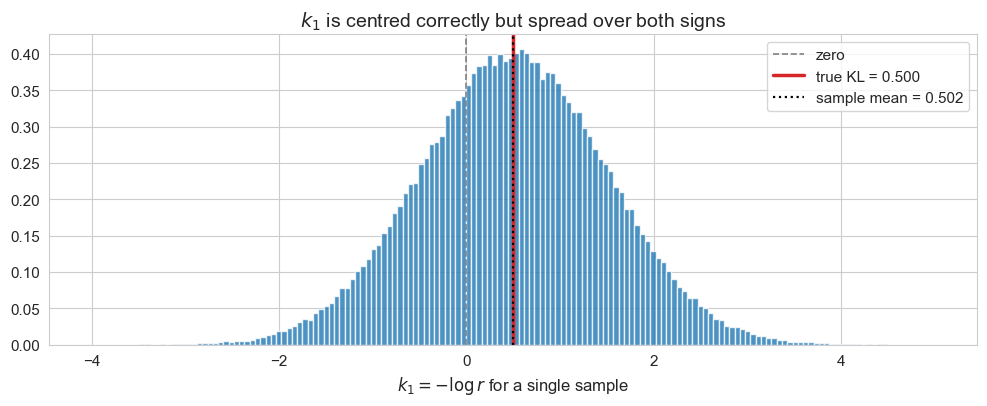

In [6]:
p_dist, q_dist = stats.norm(1, 1), stats.norm(0, 1)   # KL[q,p] = 0.5
true_kl = kl_gauss(0, 1, 1, 1)

x = q_dist.rvs(size=200_000, random_state=np.random.default_rng(1))
logr = p_dist.logpdf(x) - q_dist.logpdf(x)            # log r, r = p/q
k1 = -logr

print(f"true KL[q,p] = {true_kl:.6f}\n")
print(f"k1 mean over 200,000 samples : {k1.mean():.6f}   (should equal the true KL)")
print(f"k1 std  of a single sample   : {k1.std():.6f}")
print(f"fraction of samples NEGATIVE : {(k1 < 0).mean():.3f}   <- the problem")
print(f"range of k1                  : [{k1.min():.2f}, {k1.max():.2f}]")

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(k1, bins=160, range=(-4, 5), color='C0', alpha=.8, density=True)
ax.axvline(0, color='grey', lw=1.2, ls='--', label='zero')
ax.axvline(true_kl, color='C3', lw=2.5, label=f'true KL = {true_kl:.3f}')
ax.axvline(k1.mean(), color='k', lw=1.6, ls=':', label=f'sample mean = {k1.mean():.3f}')
ax.set_xlabel("$k_1 = -\\log r$ for a single sample"); ax.legend()
ax.set_title("$k_1$ is centred correctly but spread over both signs")
plt.tight_layout(); plt.show()

---
## 4. Bias and variance — what the words mean

Two different ways an estimator can be wrong.

- **Bias** = *systematically* off. Average it over infinitely many samples and you still do
  not get the right answer. $\text{bias} = \mathbb{E}[\hat\theta] - \theta$.
- **Variance** = *noisy*. It is right on average, but any particular run may be far off.

The archery picture: bias is aiming at the wrong spot; variance is a shaky hand.

| | low variance | high variance |
|---|---|---|
| **unbiased** | ideal — $k_3$ | right on average, needs many samples — $k_1$ |
| **biased** | consistently slightly off — $k_2$ | worst case |

Why both matter: with $n$ samples the standard error shrinks like $1/\sqrt{n}$, but the bias
**does not shrink at all**. Halving the noise costs 4× the samples; halving the bias costs a
better estimator.

true KL = 0.500000;  each run averages 500 samples, 4000 runs

        mean of runs        BIAS   std of runs        RMSE
------------------------------------------------------------
   k1       0.499104   -0.000896      0.044802    0.044811
   k2       0.624379   +0.124379      0.038774    0.130283
   k3       0.500022   +0.000022      0.038417    0.038417


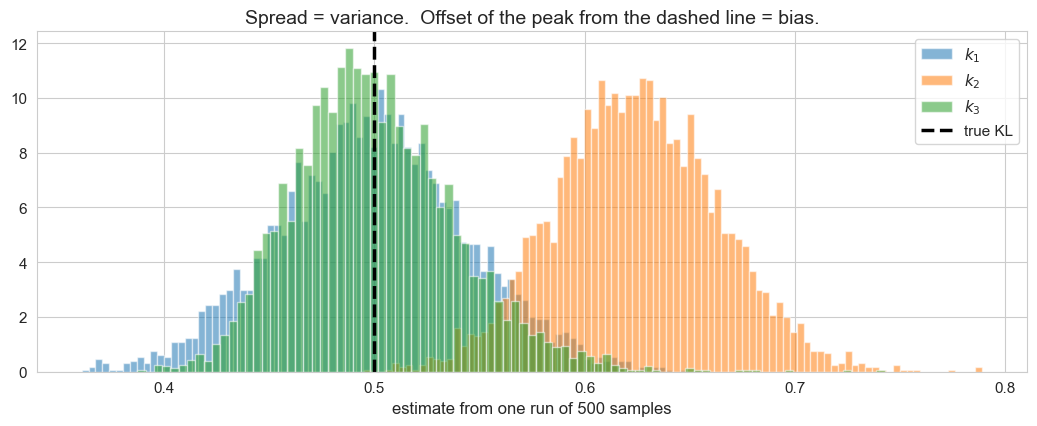


k1 is centred on the truth but wide.  k2 is narrow but shifted right (bias).
k3 is narrow AND centred -- both good properties at once.


In [7]:
def estimators(logr):
    r = np.exp(logr)
    return {"k1": -logr, "k2": 0.5*logr**2, "k3": (r - 1) - logr}

# Repeat the whole experiment many times to SEE bias and variance separately.
def repeat_experiment(p_dist, q_dist, n_per_run, n_runs, seed=0):
    g = np.random.default_rng(seed)
    out = {k: [] for k in ("k1", "k2", "k3")}
    for _ in range(n_runs):
        x = q_dist.rvs(size=n_per_run, random_state=g)
        lr = p_dist.logpdf(x) - q_dist.logpdf(x)
        for k, v in estimators(lr).items():
            out[k].append(v.mean())
    return {k: np.array(v) for k, v in out.items()}

runs = repeat_experiment(p_dist, q_dist, n_per_run=500, n_runs=4000)
print(f"true KL = {true_kl:.6f};  each run averages 500 samples, 4000 runs\n")
print(f"{'':>5}{'mean of runs':>15}{'BIAS':>12}{'std of runs':>14}{'RMSE':>12}")
print("-" * 60)
for k, v in runs.items():
    bias = v.mean() - true_kl
    print(f"{k:>5}{v.mean():>15.6f}{bias:>+12.6f}{v.std():>14.6f}"
          f"{np.sqrt(bias**2 + v.std()**2):>12.6f}")

fig, ax = plt.subplots(figsize=(10.5, 4.4))
for k, c in [("k1",'C0'), ("k2",'C1'), ("k3",'C2')]:
    ax.hist(runs[k], bins=90, alpha=.55, color=c, density=True, label=f"${k[0]}_{k[1]}$")
ax.axvline(true_kl, color='k', lw=2.5, ls='--', label='true KL')
ax.set_xlabel("estimate from one run of 500 samples"); ax.legend()
ax.set_title("Spread = variance.  Offset of the peak from the dashed line = bias.")
plt.tight_layout(); plt.show()

print("\nk1 is centred on the truth but wide.  k2 is narrow but shifted right (bias).")
print("k3 is narrow AND centred -- both good properties at once.")

---
## 5. $k_2$ — squaring the log-ratio

The trick Schulman says he had been using in code:

$$k_2 = \tfrac12\big(\log r\big)^2 = \tfrac12\big(\log p(x) - \log q(x)\big)^2$$

Two things are immediately better than $k_1$:

- it is **always $\ge 0$**, like the quantity it estimates;
- each sample says *how far apart* $p$ and $q$ are at that point, regardless of direction.

Squaring throws away the sign, which is exactly the noise we wanted rid of. The cost is that
$k_2$ is **biased** — but, remarkably, barely.

true KL[q,p] = 0.500000   (p=N(1,1), q=N(0,1))

             mean        bias   bias/true       std   std/true      min
------------------------------------------------------------------------
   k1    0.502483   +0.002483     +0.0050    0.9988      1.998  -3.9064
   k2    0.625026   +0.125026     +0.2501    0.8708      1.742   0.0000

k2 never goes negative (min >= 0) and its spread is far smaller.
But its mean sits above the true KL: that is the bias.


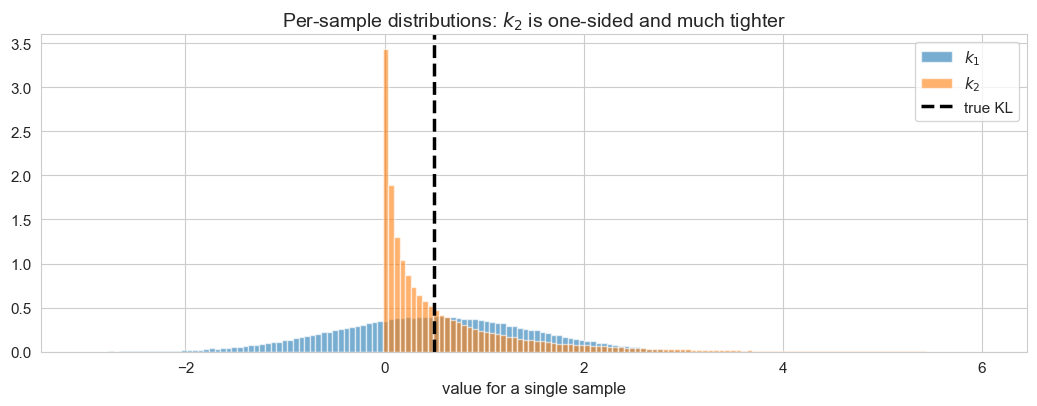

In [8]:
k2 = 0.5 * logr**2
print(f"true KL[q,p] = {true_kl:.6f}   (p=N(1,1), q=N(0,1))\n")
print(f"{'':>5}{'mean':>12}{'bias':>12}{'bias/true':>12}{'std':>10}{'std/true':>11}{'min':>9}")
print("-" * 72)
for name, v in [("k1", k1), ("k2", k2)]:
    print(f"{name:>5}{v.mean():>12.6f}{v.mean()-true_kl:>+12.6f}"
          f"{(v.mean()-true_kl)/true_kl:>+12.4f}{v.std():>10.4f}"
          f"{v.std()/true_kl:>11.3f}{v.min():>9.4f}")
print("\nk2 never goes negative (min >= 0) and its spread is far smaller.")
print("But its mean sits above the true KL: that is the bias.")

fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.hist(k1, bins=160, range=(-3, 6), alpha=.6, density=True, color='C0', label='$k_1$')
ax.hist(k2, bins=160, range=(-3, 6), alpha=.6, density=True, color='C1', label='$k_2$')
ax.axvline(true_kl, color='k', lw=2.5, ls='--', label='true KL')
ax.set_xlabel("value for a single sample"); ax.legend()
ax.set_title("Per-sample distributions: $k_2$ is one-sided and much tighter")
plt.tight_layout(); plt.show()

---
## 6. Why $k_2$ works — $f$-divergences agree to second order

Squaring the log-ratio looks arbitrary. It is not. Here is the reason, slowly.

An **$f$-divergence** is anything of the form

$$D_f(p,q) = \mathbb{E}_{x\sim q}\!\left[f\!\left(\tfrac{p(x)}{q(x)}\right)\right]
= \mathbb{E}_{x \sim q}[f(r)]$$

for a **convex** $f$ with $f(1) = 0$. Many familiar quantities are of this shape:

| divergence | $f(x)$ |
|---|---|
| $\mathrm{KL}[q,p]$ | $-\log x$ |
| $\mathrm{KL}[p,q]$ | $x\log x$ |
| what $k_2$ estimates | $\tfrac12(\log x)^2$ |
| $\chi^2$ | $(x-1)^2$ |

**The key non-obvious fact.** Every $f$-divergence with differentiable $f$ looks like the
*same* quadratic when $q$ is close to $p$:

$$D_f(p_0, p_\theta) = \tfrac{f''(1)}{2}\,\theta^\top F\,\theta + O(\theta^3)$$

with $F$ the Fisher information matrix. So two $f$-divergences agree to second order **iff
they have the same $f''(1)$**.

Check the two we care about:

- $f(x) = -\log x \;\Rightarrow\; f''(x) = 1/x^2 \;\Rightarrow\; f''(1) = 1$
- $f(x) = \tfrac12(\log x)^2 \;\Rightarrow\; f''(x) = \frac{1-\log x}{x^2} \;\Rightarrow\; f''(1) = 1$

Same. That is why $k_2$'s bias is tiny when $p \approx q$ — it is only third order.

In [9]:
import sympy as sp
xsym = sp.symbols('xsym', positive=True)   # note: do NOT shadow the sample array x
print("checking f(1)=0 and f''(1) for each f:\n")
hdr2 = "f''(1)"
print(f"{'divergence':<26}{'f(x)':<20}{'f(1)':>8}{hdr2:>12}")
print("-" * 68)
for name, fx in [("KL[q,p]        (k1)", -sp.log(xsym)),
                 ("what k2 estimates",   sp.Rational(1,2)*sp.log(xsym)**2),
                 ("KL[p,q]",             xsym*sp.log(xsym)),
                 ("chi-squared",         (xsym-1)**2)]:
    f1  = sp.simplify(fx.subs(xsym, 1))
    f2  = sp.simplify(sp.diff(fx, xsym, 2).subs(xsym, 1))
    print(f"{name:<26}{str(fx).replace("xsym","x"):<20}{str(f1):>8}{str(f2):>12}")
print("\nThe first three all have f''(1) = 1 -> identical to second order near p=q.")
print("chi-squared has f''(1) = 2, so it is twice KL to leading order.")

checking f(1)=0 and f''(1) for each f:

divergence                f(x)                    f(1)      f''(1)
--------------------------------------------------------------------
KL[q,p]        (k1)       -log(x)                    0           1
what k2 estimates         log(x)**2/2                0           1
KL[p,q]                   x*log(x)                   0           1
chi-squared               (x - 1)**2                 0           2

The first three all have f''(1) = 1 -> identical to second order near p=q.
chi-squared has f''(1) = 2, so it is twice KL to leading order.


In [10]:
# Verify the claim numerically: bias of k2 should vanish FASTER than the KL itself.
print("q = N(0,1) fixed; move p closer and closer.\n")
print(f"{'mu_p':>8}{'true KL':>12}{'E[k2]':>12}{'bias':>13}{'bias/KL':>11}{'bias/KL^2':>12}")
print("-" * 70)
g = np.random.default_rng(7)
for mu in [1.0, 0.5, 0.25, 0.1, 0.05, 0.02]:
    pd, qd = stats.norm(mu, 1), stats.norm(0, 1)
    kl = kl_gauss(0, 1, mu, 1)
    xs_ = qd.rvs(size=8_000_000, random_state=g)
    lr = pd.logpdf(xs_) - qd.logpdf(xs_)
    b = (0.5*lr**2).mean() - kl
    print(f"{mu:>8.2f}{kl:>12.6f}{(0.5*lr**2).mean():>12.6f}{b:>+13.6f}"
          f"{b/kl:>+11.4f}{b/kl**2:>+12.4f}")
print("\nbias/KL  -> 0    : the bias is NOT proportional to KL")
print("bias/KL^2-> const: it is second order in KL, i.e. third order in the mean gap.")
print("That is the f''(1) agreement showing up as a number.")

q = N(0,1) fixed; move p closer and closer.

    mu_p     true KL       E[k2]         bias    bias/KL   bias/KL^2
----------------------------------------------------------------------


    1.00    0.500000    0.625337    +0.125337    +0.2507     +0.5013


    0.50    0.125000    0.132823    +0.007823    +0.0626     +0.5006


    0.25    0.031250    0.031745    +0.000495    +0.0158     +0.5066


    0.10    0.005000    0.005013    +0.000013    +0.0025     +0.5085


    0.05    0.001250    0.001249    -0.000001    -0.0006     -0.4886


    0.02    0.000200    0.000200    +0.000000    +0.0000     +0.2078

bias/KL  -> 0    : the bias is NOT proportional to KL
bias/KL^2-> const: it is second order in KL, i.e. third order in the mean gap.
That is the f''(1) agreement showing up as a number.


---
## 7. Control variates — the idea that fixes everything

This is the part worth understanding properly, because it is a general technique.

**The problem.** $k_1$ is unbiased but noisy. We want to keep the unbiasedness and kill the
noise.

**The trick.** Add something whose average is *exactly zero*. That cannot change the mean, so
the estimator stays unbiased. But if the thing you add is **negatively correlated** with your
estimator, the two sets of fluctuations partly cancel and the variance drops.

$$\hat\theta_{\text{new}} = \hat\theta + \lambda\,\underbrace{c}_{\mathbb{E}[c]=0}$$

### 7.1 A tiny example with no KL in it at all

Forget KL for a moment. Suppose you want $\mathbb{E}[e^U]$ for $U$ uniform on $[0,1]$. The
true answer is $e - 1 \approx 1.71828$, but pretend you can only sample.

**Naive:** draw $U_1,\dots,U_n$, average $e^{U_i}$. Works, but noisy.

**With a control variate:** you happen to know something for free — $\mathbb{E}[U] = 0.5$
exactly. So $U - 0.5$ has mean zero, and

$$e^{U} - \lambda\,(U - 0.5)$$

has the *same* mean for any $\lambda$. And $e^U$ and $U$ move together (when $U$ is large,
$e^U$ is large), so subtracting a multiple of $U - 0.5$ cancels much of the wobble.

target: E[e^U] = e - 1 = 1.718282

correlation between e^U and U : +0.9918  (strongly positive)
so we SUBTRACT a multiple of (U - 0.5)

   lambda         mean        std   variance cut
--------------------------------------------------
     0.00     1.719035   0.491955          0.0%
     0.50     1.718803   0.349313         49.6%
     1.00     1.718572   0.208970         82.0%
     1.69     1.718253   0.062770         98.4%  <- best
     2.50     1.717878   0.241889         75.8%

Every row has the SAME mean (still unbiased) but the spread collapses.
At the best lambda the variance is cut by ~98%: same answer, 50x fewer samples
needed for the same precision. That is a control variate, and it is free.


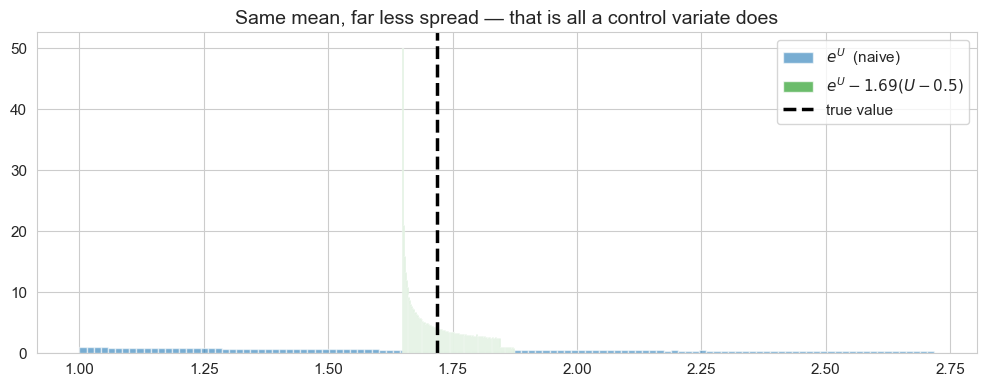

In [11]:
g = np.random.default_rng(3)
U = g.uniform(size=400_000)
naive = np.exp(U)
truth = np.e - 1

print(f"target: E[e^U] = e - 1 = {truth:.6f}\n")
print(f"correlation between e^U and U : {np.corrcoef(naive, U)[0,1]:+.4f}  (strongly positive)")
print("so we SUBTRACT a multiple of (U - 0.5)\n")
print(f"{'lambda':>9}{'mean':>13}{'std':>11}{'variance cut':>15}")
print("-" * 50)
base_sd = naive.std()
for lam in [0.0, 0.5, 1.0, 1.69, 2.5]:
    v = naive - lam*(U - 0.5)
    tag = "  <- best" if abs(lam-1.69) < 1e-9 else ""
    print(f"{lam:>9.2f}{v.mean():>13.6f}{v.std():>11.6f}{1 - (v.std()/base_sd)**2:>14.1%}{tag}")

print("\nEvery row has the SAME mean (still unbiased) but the spread collapses.")
print("At the best lambda the variance is cut by ~98%: same answer, 50x fewer samples")
print("needed for the same precision. That is a control variate, and it is free.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(naive, bins=120, alpha=.6, density=True, color='C0', label='$e^U$  (naive)')
ax.hist(naive - 1.69*(U-0.5), bins=120, alpha=.7, density=True, color='C2',
        label='$e^U - 1.69(U-0.5)$')
ax.axvline(truth, color='k', lw=2.5, ls='--', label='true value')
ax.legend(); ax.set_title("Same mean, far less spread — that is all a control variate does")
plt.tight_layout(); plt.show()

### 7.2 Back to KL — what is free here?

Exactly the same move. We need a quantity with mean zero that we already have lying around.

**What zero-mean quantity is available here?** Just one obvious candidate, and it is free:

$$\mathbb{E}_{x\sim q}[r] = \sum_x q(x)\,\frac{p(x)}{q(x)} = \sum_x p(x) = 1
\qquad\Longrightarrow\qquad \mathbb{E}_{x\sim q}[\,r - 1\,] = 0$$

$r - 1$ costs nothing extra — you already computed $r$. So for **any** $\lambda$,

$$-\log r + \lambda\,(r-1)$$

is an unbiased estimator of $\mathrm{KL}[q,p]$.

is r - 1 really mean-zero?   E[r] = 0.996987   (exactly 1 in the limit)
                       E[r-1] = -0.003013
correlation between k1 and (r-1): -0.7610  <- strongly NEGATIVE

Negative correlation is exactly what we want: when k1 happens to be too
low, (r-1) happens to be too high, so adding them cancels noise.



    lambda    mean (unbiased?)         std
--------------------------------------------
    0.0000            0.502483     0.99878
    0.5000            0.500977     0.65623
    0.5854            0.500720     0.64802  <- variance-optimal
    1.0000            0.499471     0.85149  <- k3
    2.0000            0.496458     1.97426


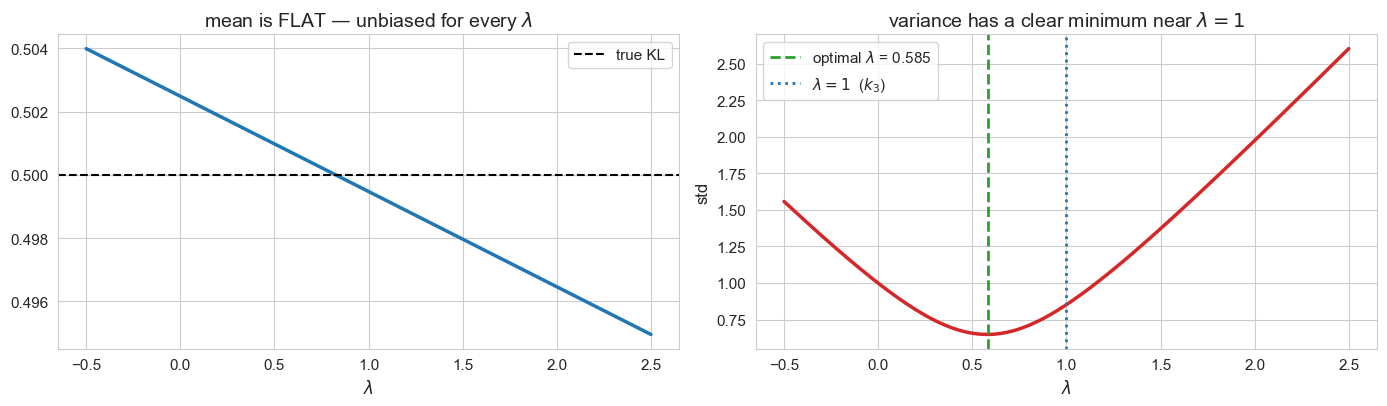


The variance-minimising lambda is 0.5854 -- close to 1, but it depends on p
and q and cannot be computed analytically in general. So we need another reason
to pick a specific lambda. That is the next section.


In [12]:
r = np.exp(logr)
print(f"is r - 1 really mean-zero?   E[r] = {r.mean():.6f}   (exactly 1 in the limit)")
print(f"                       E[r-1] = {(r-1).mean():+.6f}")
print(f"correlation between k1 and (r-1): {np.corrcoef(k1, r-1)[0,1]:+.4f}  <- strongly NEGATIVE")
print("\nNegative correlation is exactly what we want: when k1 happens to be too")
print("low, (r-1) happens to be too high, so adding them cancels noise.\n")

lams = np.linspace(-0.5, 2.5, 200)
sds = np.array([(k1 + L*(r-1)).std() for L in lams])
means = np.array([(k1 + L*(r-1)).mean() for L in lams])
best = lams[np.argmin(sds)]

print(f"{'lambda':>10}{'mean (unbiased?)':>20}{'std':>12}")
print("-" * 44)
for L in [0.0, 0.5, best, 1.0, 2.0]:
    v = k1 + L*(r-1)
    tag = "  <- variance-optimal" if abs(L-best) < 1e-9 else ("  <- k3" if L == 1.0 else "")
    print(f"{L:>10.4f}{v.mean():>20.6f}{v.std():>12.5f}{tag}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(lams, means, lw=2.5, color='C0')
axes[0].axhline(true_kl, color='k', ls='--', lw=1.5, label='true KL')
axes[0].set_xlabel("$\\lambda$"); axes[0].set_title("mean is FLAT — unbiased for every $\\lambda$")
axes[0].legend()
axes[1].plot(lams, sds, lw=2.5, color='C3')
axes[1].axvline(best, color='C2', ls='--', lw=2, label=f'optimal $\\lambda$ = {best:.3f}')
axes[1].axvline(1.0, color='C0', ls=':', lw=2, label='$\\lambda = 1$  ($k_3$)')
axes[1].set_xlabel("$\\lambda$"); axes[1].set_ylabel("std"); axes[1].legend()
axes[1].set_title("variance has a clear minimum near $\\lambda = 1$")
plt.tight_layout(); plt.show()

print(f"\nThe variance-minimising lambda is {best:.4f} -- close to 1, but it depends on p")
print("and q and cannot be computed analytically in general. So we need another reason")
print("to pick a specific lambda. That is the next section.")

---
## 8. $k_3$ — choosing $\lambda = 1$

The variance-optimal $\lambda$ is not available in closed form. Schulman's move is to pick
$\lambda = 1$ for a different and better reason: **it makes the estimator non-negative**.

The fact used is the standard inequality

$$\log x \;\le\; x - 1 \qquad \text{for all } x > 0$$

with equality only at $x=1$. Rearranged, $(x-1) - \log x \ge 0$. So setting $\lambda = 1$:

$$\boxed{\;k_3 = (r-1) - \log r \;\ge\; 0\;}$$

Now the estimator has every property we wanted:

- **unbiased** — because $\mathbb{E}[r-1] = 0$ (§7);
- **never negative** — like the KL it estimates;
- **low variance** — empirically as good as $k_2$, sometimes better.

Geometrically $k_3$ is the **vertical gap between $\log x$ and its tangent line at $x=1$**,
which is the line $x-1$.

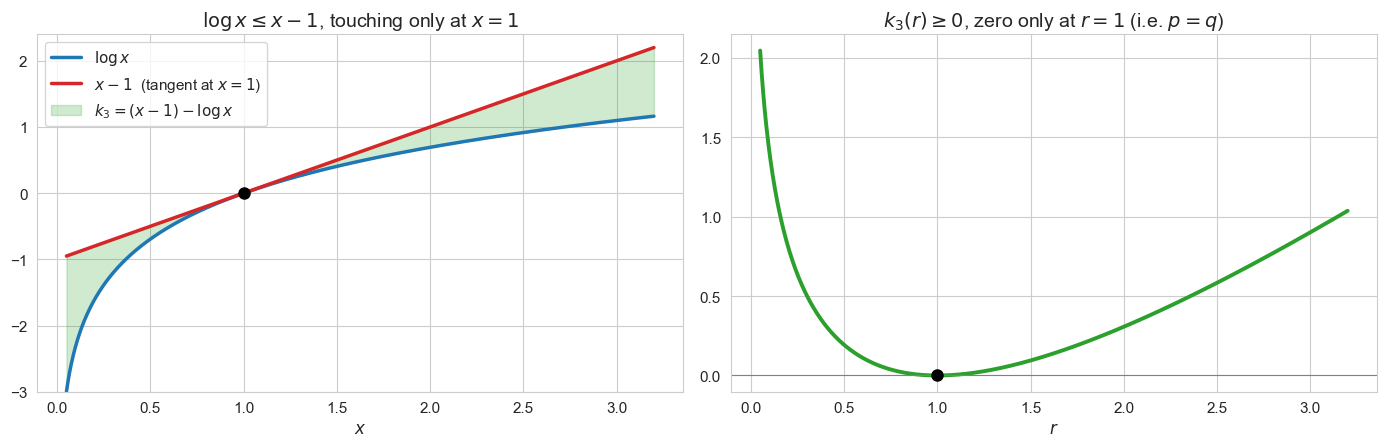

minimum of k3 over 200,000 samples: 2.808e-12   (never negative)
minimum of k1 over the same       : -3.9064   (often negative)

             mean    bias/true    std/true         min
--------------------------------------------------------
   k1    0.502483     +0.00497      1.9976     -3.9064
   k2    0.625026     +0.25005      1.7415      0.0000
   k3    0.499471     -0.00106      1.7030      0.0000

k3: unbiased like k1, tight like k2, non-negative like KL itself.


In [13]:
xx = np.linspace(0.05, 3.2, 800)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(xx, np.log(xx), lw=2.5, color='C0', label='$\\log x$')
axes[0].plot(xx, xx - 1, lw=2.5, color='C3', label='$x - 1$  (tangent at $x=1$)')
axes[0].fill_between(xx, np.log(xx), xx-1, alpha=.22, color='C2',
                     label='$k_3 = (x-1) - \\log x$')
axes[0].plot(1, 0, 'ko', ms=8)
axes[0].set_ylim(-3, 2.4); axes[0].legend(); axes[0].set_xlabel("$x$")
axes[0].set_title("$\\log x \\leq x-1$, touching only at $x=1$")

axes[1].plot(xx, (xx-1) - np.log(xx), lw=2.8, color='C2')
axes[1].axhline(0, color='grey', lw=.8); axes[1].plot(1, 0, 'ko', ms=8)
axes[1].set_xlabel("$r$"); axes[1].set_title("$k_3(r) \\geq 0$, zero only at $r=1$ (i.e. $p=q$)")
plt.tight_layout(); plt.show()

k3 = (r - 1) - logr
print(f"minimum of k3 over 200,000 samples: {k3.min():.3e}   (never negative)")
print(f"minimum of k1 over the same       : {k1.min():.4f}   (often negative)\n")
print(f"{'':>5}{'mean':>12}{'bias/true':>13}{'std/true':>12}{'min':>12}")
print("-" * 56)
for nm, v in [("k1", k1), ("k2", k2), ("k3", k3)]:
    print(f"{nm:>5}{v.mean():>12.6f}{(v.mean()-true_kl)/true_kl:>+13.5f}"
          f"{v.std()/true_kl:>12.4f}{v.min():>12.4f}")
print("\nk3: unbiased like k1, tight like k2, non-negative like KL itself.")

---
## 9. The Bregman picture, and the general recipe

"Distance between a convex function and its tangent" is a named construction — the **Bregman
divergence**. It is automatically non-negative, because a convex function lies above every
one of its tangent lines.

That gives a recipe for *any* $f$-divergence. Since $f$ is convex and $\mathbb{E}_q[r] = 1$,
the quantity

$$f(r) \;-\; f'(1)\,(r-1)$$

is an always-non-negative, unbiased estimator of $D_f(p,q)$ from samples $x\sim q$.

Feeding in the two KLs:

| target | $f(x)$ | $f'(1)$ | estimator |
|---|---|---|---|
| $\mathrm{KL}[q,p]$ | $-\log x$ | $-1$ | $(r-1) - \log r \;=\; k_3$ |
| $\mathrm{KL}[p,q]$ | $x\log x$ | $1$ | $r\log r - (r-1)$ |

Same recipe, two answers. $k_3$ was not pulled out of a hat.

applying   f(r) - f'(1)(r-1)   mechanically:

   KL[q,p]        f(x) = -log(x)        f'(1) = -1   -> estimator: x - log(x) - 1
   KL[p,q]        f(x) = x*log(x)       f'(1) = 1    -> estimator: x*log(x) - x + 1
   chi-squared    f(x) = (x - 1)**2     f'(1) = 0    -> estimator: (x - 1)**2

and each is non-negative because a convex function lies above its tangent:


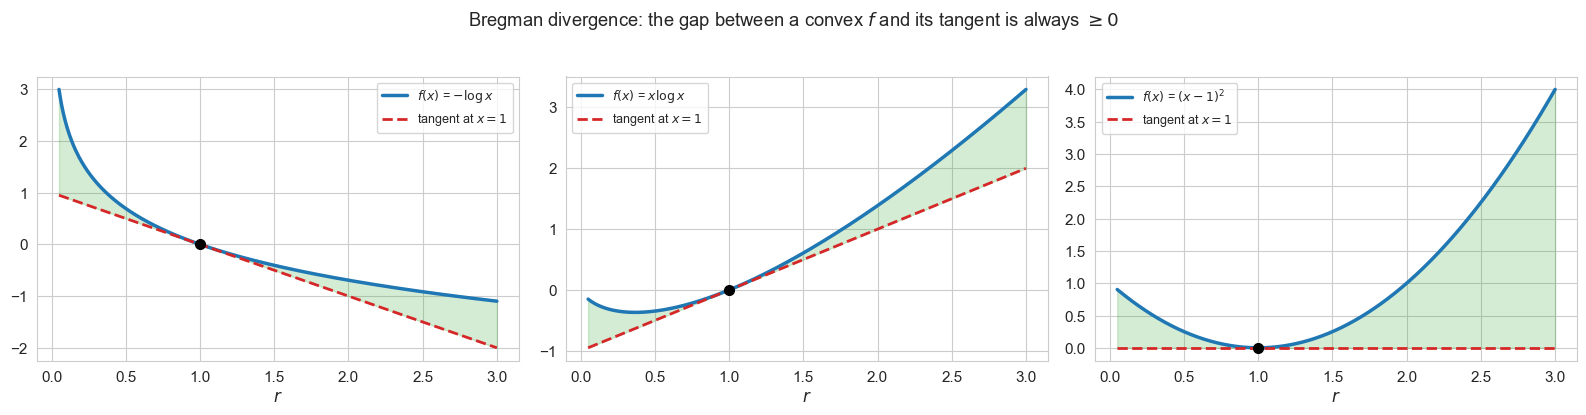

In [14]:
import sympy as sp
xs_ = sp.symbols('x', positive=True)
print("applying   f(r) - f'(1)(r-1)   mechanically:\n")
for name, fx in [("KL[q,p]", -sp.log(xs_)), ("KL[p,q]", xs_*sp.log(xs_)),
                 ("chi-squared", (xs_-1)**2)]:
    fp1 = sp.diff(fx, xs_).subs(xs_, 1)
    est = sp.simplify(fx - fp1*(xs_ - 1))
    print(f"   {name:<14} f(x) = {str(fx):<14} f'(1) = {str(fp1):<4} -> estimator: {est}")

print("\nand each is non-negative because a convex function lies above its tangent:")
xx2 = np.linspace(0.05, 3.0, 600)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nm, f, fp1) in zip(axes, [("$-\\log x$", lambda t: -np.log(t), -1),
                                   ("$x\\log x$", lambda t: t*np.log(t), 1),
                                   ("$(x-1)^2$", lambda t: (t-1)**2, 0)]):
    ax.plot(xx2, f(xx2), lw=2.5, color='C0', label=f"$f(x)$ = {nm}")
    tangent = f(1.0) + fp1*(xx2 - 1)
    ax.plot(xx2, tangent, lw=2, color='C3', ls='--', label="tangent at $x=1$")
    ax.fill_between(xx2, tangent, f(xx2), alpha=.2, color='C2')
    ax.plot(1, f(1.0), 'ko', ms=7); ax.legend(fontsize=9); ax.set_xlabel("$r$")
plt.suptitle("Bregman divergence: the gap between a convex $f$ and its tangent is always $\\geq 0$", y=1.03)
plt.tight_layout(); plt.show()

---
## 10. Reproducing the post's experiments

Schulman reports two tables. Let us regenerate both. The original used PyTorch; this is the
same computation in numpy, so the numbers should match to sampling noise.

**Experiment 1.** Two Gaussians one tenth of a standard deviation apart — very close, so the
true KL is tiny: $0.1^2/2 = 0.005$.

In [15]:
def run_table(mu_p, sigma_p=1.0, mu_q=0.0, sigma_q=1.0, n=10_000_000, seed=0):
    # samples from q; r = p/q; estimators of KL[q,p]
    g = np.random.default_rng(seed)
    pd, qd = stats.norm(mu_p, sigma_p), stats.norm(mu_q, sigma_q)
    x = qd.rvs(size=n, random_state=g)
    lr = pd.logpdf(x) - qd.logpdf(x)
    r = np.exp(lr)
    true = kl_gauss(mu_q, sigma_q, mu_p, sigma_p)          # KL[q, p]
    est = {"k1": -lr, "k2": 0.5*lr**2, "k3": (r - 1) - lr}
    rows = []
    for name, v in est.items():
        rows.append((name, (v.mean()-true)/true, v.std()/true))
    return true, rows

true1, rows1 = run_table(mu_p=0.1)
print(f"EXPERIMENT 1:  q = N(0,1),  p = N(0.1,1)     true KL[q,p] = {true1:.4f}\n")
print(f"{'':>5}{'bias/true':>14}{'stdev/true':>14}     post's values")
print("-" * 62)
post1 = {"k1": ("0", "20"), "k2": ("0.002", "1.42"), "k3": ("0", "1.42")}
for name, b, s in rows1:
    print(f"{name:>5}{b:>14.4f}{s:>14.2f}     bias {post1[name][0]:<6} stdev {post1[name][1]}")
print("\nk1's noise is 20x the quantity being measured. k2 and k3 are ~1.4x.")
print("k2's bias here is 0.2% -- essentially nothing.")

EXPERIMENT 1:  q = N(0,1),  p = N(0.1,1)     true KL[q,p] = 0.0050

          bias/true    stdev/true     post's values
--------------------------------------------------------------
   k1        0.0062         19.99     bias 0      stdev 20
   k2        0.0015          1.42     bias 0.002  stdev 1.42
   k3       -0.0010          1.42     bias 0      stdev 1.42

k1's noise is 20x the quantity being measured. k2 and k3 are ~1.4x.
k2's bias here is 0.2% -- essentially nothing.


**Experiment 2.** Push the distributions a full standard deviation apart. True KL $= 0.5$.
Now $k_2$'s bias becomes serious.

In [16]:
true2, rows2 = run_table(mu_p=1.0)
print(f"EXPERIMENT 2:  q = N(0,1),  p = N(1,1)       true KL[q,p] = {true2:.4f}\n")
print(f"{'':>5}{'bias/true':>14}{'stdev/true':>14}     post's values")
print("-" * 62)
post2 = {"k1": ("0", "2"), "k2": ("0.25", "1.73"), "k3": ("0", "1.7")}
for name, b, s in rows2:
    print(f"{name:>5}{b:>14.4f}{s:>14.2f}     bias {post2[name][0]:<6} stdev {post2[name][1]}")

print("\nk2 now overestimates by 25%. k3 is unbiased AND has slightly lower")
print("variance than k2. As the post puts it, k3 is strictly better.")

EXPERIMENT 2:  q = N(0,1),  p = N(1,1)       true KL[q,p] = 0.5000

          bias/true    stdev/true     post's values
--------------------------------------------------------------
   k1        0.0006          2.00     bias 0      stdev 2
   k2        0.2493          1.73     bias 0.25   stdev 1.73
   k3       -0.0007          1.69     bias 0      stdev 1.7

k2 now overestimates by 25%. k3 is unbiased AND has slightly lower
variance than k2. As the post puts it, k3 is strictly better.


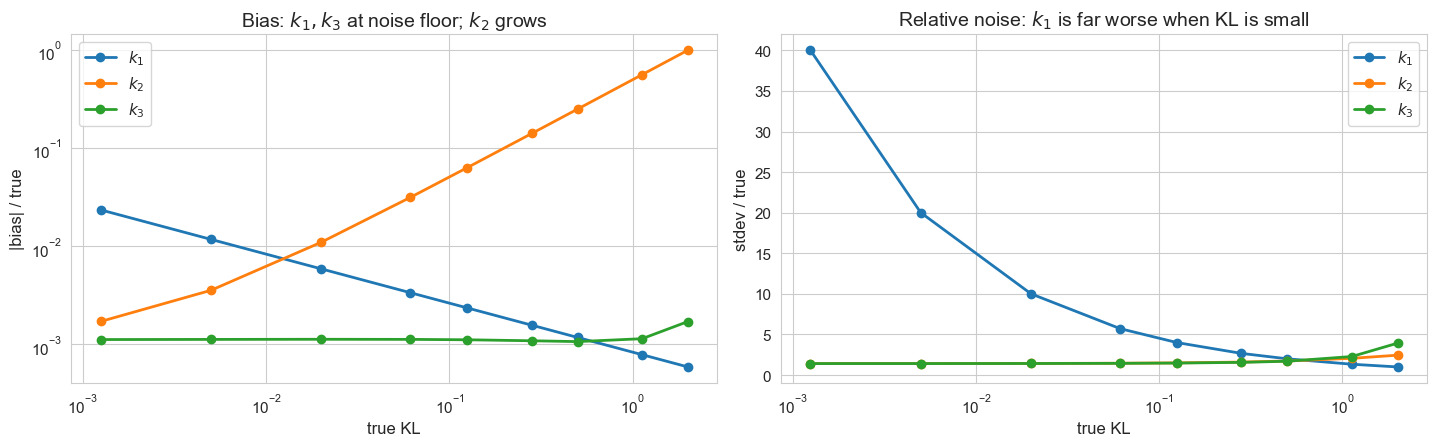

   true KL   k1 std/true   k2 std/true   k3 std/true   k2 bias/true
--------------------------------------------------------------------
    0.0012         40.02          1.42          1.42         0.0017
    0.0050         20.01          1.42          1.42         0.0036
    0.0200         10.01          1.43          1.42         0.0110
    0.0613          5.72          1.46          1.45         0.0315
    0.1250          4.00          1.50          1.48         0.0633
    0.2812          2.67          1.60          1.56         0.1413
    0.5000          2.00          1.73          1.70         0.2505
    1.1250          1.33          2.06          2.28         0.5627
    2.0000          1.00          2.45          3.93         0.9999

The smaller the true KL, the worse k1 looks -- and small KL is exactly the
regime you care about when monitoring a policy that should not drift far.


In [17]:
# Sweep the gap to see the whole picture at once.
mus = np.array([0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.0])
res = {k: {"bias": [], "std": []} for k in ("k1","k2","k3")}
kls = []
for mu in mus:
    t, rows = run_table(mu_p=mu, n=2_000_000, seed=11)
    kls.append(t)
    for name, b, s in rows:
        res[name]["bias"].append(b); res[name]["std"].append(s)
kls = np.array(kls)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
for k, c in [("k1",'C0'), ("k2",'C1'), ("k3",'C2')]:
    axes[0].plot(kls, np.abs(res[k]["bias"]) + 1e-12, 'o-', color=c, lw=2, label=f"$k_{k[1]}$")
    axes[1].plot(kls, res[k]["std"], 'o-', color=c, lw=2, label=f"$k_{k[1]}$")
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel("true KL"); axes[0].set_ylabel("|bias| / true")
axes[0].set_title("Bias: $k_1,k_3$ at noise floor; $k_2$ grows")
axes[0].legend()
axes[1].set_xscale('log')
axes[1].set_xlabel("true KL"); axes[1].set_ylabel("stdev / true")
axes[1].set_title("Relative noise: $k_1$ is far worse when KL is small")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"{'true KL':>10}{'k1 std/true':>14}{'k2 std/true':>14}{'k3 std/true':>14}{'k2 bias/true':>15}")
print("-" * 68)
for i, t in enumerate(kls):
    print(f"{t:>10.4f}{res['k1']['std'][i]:>14.2f}{res['k2']['std'][i]:>14.2f}"
          f"{res['k3']['std'][i]:>14.2f}{res['k2']['bias'][i]:>15.4f}")
print("\nThe smaller the true KL, the worse k1 looks -- and small KL is exactly the")
print("regime you care about when monitoring a policy that should not drift far.")

---
## 11. The *other* KL divergence

Everything so far estimated $\mathrm{KL}[q,p]$ — the average taken over $q$, which is the
distribution we sample from. That is the convenient case.

What if you want $\mathrm{KL}[p,q]$, averaged over $p$, but you can still only sample from
$q$? Use the §9 recipe with $f(x) = x\log x$, giving $f'(1) = 1$:

$$\mathrm{KL}[p,q] \;\approx\; r\log r - (r-1), \qquad x \sim q$$

Still non-negative, still unbiased, still only needs samples from $q$.

In [18]:
mu_p = 0.8
pd, qd = stats.norm(mu_p, 1), stats.norm(0, 1)
g = np.random.default_rng(5)
x = qd.rvs(size=4_000_000, random_state=g)
lr = pd.logpdf(x) - qd.logpdf(x)
r = np.exp(lr)

kl_qp = kl_gauss(0, 1, mu_p, 1)      # KL[q,p]
kl_pq = kl_gauss(mu_p, 1, 0, 1)      # KL[p,q]

est_qp = (r - 1) - lr                 # k3
est_pq = r*lr - (r - 1)               # the other one

print(f"p = N({mu_p},1), q = N(0,1);  we sample ONLY from q\n")
print(f"{'target':<12}{'true':>12}{'estimate':>14}{'rel error':>13}{'min value':>12}")
print("-" * 64)
print(f"{'KL[q,p]':<12}{kl_qp:>12.6f}{est_qp.mean():>14.6f}"
      f"{(est_qp.mean()-kl_qp)/kl_qp:>+13.2e}{est_qp.min():>12.2e}")
print(f"{'KL[p,q]':<12}{kl_pq:>12.6f}{est_pq.mean():>14.6f}"
      f"{(est_pq.mean()-kl_pq)/kl_pq:>+13.2e}{est_pq.min():>12.2e}")
print("\nboth unbiased, both non-negative, both from the SAME samples of q.")
print("(For equal-variance Gaussians the two KLs coincide, which is why the two")
print(" 'true' numbers agree here. Section 12 uses unequal variances to separate them.)")

p = N(0.8,1), q = N(0,1);  we sample ONLY from q

target              true      estimate    rel error   min value
----------------------------------------------------------------
KL[q,p]         0.320000      0.319539    -1.44e-03    4.77e-15
KL[p,q]         0.320000      0.318886    -3.48e-03    4.82e-15

both unbiased, both non-negative, both from the SAME samples of q.
(For equal-variance Gaussians the two KLs coincide, which is why the two
 'true' numbers agree here. Section 12 uses unequal variances to separate them.)


---
## 12. The convention trap — read this one

This is the thing most likely to bite you, and it is easy to miss.

**In the post's prose:** *"Suppose $q=N(0,1)$, $p=N(0.1,1)$."*
**In the post's code:** `p = dis.Normal(loc=0, scale=1)` and `q = dis.Normal(loc=0.1, scale=1)`.

The two are **swapped**. It does not matter there, because for Gaussians with the *same
variance* $\mathrm{KL}[p,q] = \mathrm{KL}[q,p]$ — the example is accidentally symmetric, so
both readings give 0.005.

Change the variances and the symmetry breaks. Then getting the convention wrong gives a
wrong answer, silently.

**The rule to memorise:**

> Sample from the **second** argument's… no. Just remember this:
> $\mathrm{KL}[a,b] = \mathbb{E}_{x\sim a}[\log a/b]$ — **you average over the first argument.**
> $k_1,k_2,k_3$ with samples $x\sim q$ and $r = p/q$ estimate $\mathrm{KL}[q,p]$.

Also worth knowing: **PyTorch's `kl_divergence(p, q)` computes $\mathrm{KL}[p,q]$** — averaged
over its *first* argument, matching the convention above but the *opposite* of what the
estimators give you from samples of `q`.

In [19]:
# Equal variances: symmetric, so the swap is invisible.
print("EQUAL variances -- the bug hides:\n")
a, b = (0.0, 1.0), (0.1, 1.0)
print(f"   KL[N{a} , N{b}] = {kl_gauss(*a, *b):.8f}")
print(f"   KL[N{b} , N{a}] = {kl_gauss(*b, *a):.8f}   <- identical")

print("\nUNEQUAL variances -- now it matters:\n")
mu_p, sig_p = 0.5, 0.6                   # p NARROWER than q -- see section 12.1
a, b = (0.0, 1.0), (mu_p, sig_p)
print(f"   KL[N{a} , N{b}] = {kl_gauss(*a, *b):.8f}")
print(f"   KL[N{b} , N{a}] = {kl_gauss(*b, *a):.8f}   <- 2.3x different\n")

pd, qd = stats.norm(mu_p, sig_p), stats.norm(0.0, 1.0)
g = np.random.default_rng(21)
x = qd.rvs(size=6_000_000, random_state=g)
lr = pd.logpdf(x) - qd.logpdf(x)
r = np.exp(lr)

print(f"sampling from q = N(0,1), with p = N({mu_p},{sig_p}):\n")
print(f"{'estimator':<26}{'estimate':>12}{'true value':>28}{'rel err':>11}")
print("-" * 78)
for nm, est, true in [("k3 = (r-1) - log r", (r-1)-lr, kl_gauss(0,1,mu_p,sig_p)),
                      ("r log r - (r-1)",    r*lr-(r-1), kl_gauss(mu_p,sig_p,0,1))]:
    lbl = "KL[q,p] = " if nm.startswith("k3") else "KL[p,q] = "
    print(f"{nm:<26}{est.mean():>12.6f}{lbl + format(true, '.6f'):>28}"
          f"{(est.mean()-true)/true:>+11.2e}")
print("\nEach estimator locks onto exactly one of the two, to 4 decimal places.")
print("Pick the wrong formula and you get a confidently wrong number, no error message.")

EQUAL variances -- the bug hides:

   KL[N(0.0, 1.0) , N(0.1, 1.0)] = 0.00500000
   KL[N(0.1, 1.0) , N(0.0, 1.0)] = 0.00500000   <- identical

UNEQUAL variances -- now it matters:

   KL[N(0.0, 1.0) , N(0.5, 0.6)] = 0.72528549
   KL[N(0.5, 0.6) , N(0.0, 1.0)] = 0.31582562   <- 2.3x different



sampling from q = N(0,1), with p = N(0.5,0.6):

estimator                     estimate                  true value    rel err
------------------------------------------------------------------------------


k3 = (r-1) - log r            0.725290          KL[q,p] = 0.725285  +5.70e-06
r log r - (r-1)               0.315787          KL[p,q] = 0.315826  -1.22e-04

Each estimator locks onto exactly one of the two, to 4 decimal places.
Pick the wrong formula and you get a confidently wrong number, no error message.


### 12.1 When these estimators stop working

One caveat the post does not mention, and it is easy to trip over.

Everything above relies on averaging $r = p(x)/q(x)$ over samples of $q$. The mean
$\mathbb{E}_q[r]=1$ always, but the **variance** need not be finite:

$$\mathbb{E}_q[r^2] = \int \frac{p(x)^2}{q(x)}\,dx$$

If $q$ has thinner tails than $p$, this integral **diverges**, $r$ is heavy-tailed, and the
sample mean converges agonisingly slowly — you can average ten million draws and still be
several percent off with no warning.

For two Gaussians the condition is clean:

$$\mathbb{E}_q[r^2] < \infty \iff \sigma_p^2 < 2\sigma_q^2
\iff \sigma_p < \sqrt2\,\sigma_q$$

**Practical rule: sample from the *wider* distribution.** In RLHF this is usually fine, since
$p$ and $q$ are close by construction — but it is exactly why the first draft of the cell
above was wrong.

In [20]:
print("does E_q[r^2] converge?   (Gaussians, mu = 0)\n")
print(f"{'sigma_p':>9}{'sigma_q':>9}{'2/sp^2 - 1/sq^2':>18}{'E[r^2]':>14}   verdict")
print("-" * 72)
g = np.random.default_rng(4)
for sp_, sq in [(0.6,1.0), (1.0,1.0), (1.3,1.0), (1.5,1.0), (2.0,1.0)]:
    cond = 2/sp_**2 - 1/sq**2
    xx = stats.norm(0, sq).rvs(size=3_000_000, random_state=g)
    rr = np.exp(stats.norm(0, sp_).logpdf(xx) - stats.norm(0, sq).logpdf(xx))
    print(f"{sp_:>9.2f}{sq:>9.1f}{cond:>18.4f}{(rr**2).mean():>14.3f}   "
          f"{'finite' if cond > 0 else 'DIVERGES (number is meaningless)'}")

print("\nNow watch k3 converge, or fail to, in the two regimes:\n")
print(f"{'n samples':>12}{'k3, sigma_p=0.6 (good)':>26}{'k3, sigma_p=2.0 (bad)':>26}")
print("-" * 66)
true_good = kl_gauss(0, 1, 0, 0.6)
true_bad  = kl_gauss(0, 1, 0, 2.0)
for n in [10_000, 100_000, 1_000_000, 5_000_000]:
    row = []
    for sp_ in (0.6, 2.0):
        xx = stats.norm(0, 1).rvs(size=n, random_state=np.random.default_rng(n))
        lrr = stats.norm(0, sp_).logpdf(xx) - stats.norm(0, 1).logpdf(xx)
        row.append(((np.exp(lrr)-1) - lrr).mean())
    print(f"{n:>12,}{row[0]:>26.6f}{row[1]:>26.6f}")
print(f"{'true':>12}{true_good:>26.6f}{true_bad:>26.6f}")
print("\nLeft column settles monotonically. Right column does NOT: it wanders")
print("non-monotonically (5% low at 1M, then back up), because the estimate is")
print("dominated by rare huge values of r that may or may not show up in a given draw.")
print("Same formula, same code -- the difference is entirely the tails of r.")
print("With no finite variance there is no standard error, so you cannot even tell")
print("from the output how far off you are. That is what makes it dangerous.")

does E_q[r^2] converge?   (Gaussians, mu = 0)

  sigma_p  sigma_q   2/sp^2 - 1/sq^2        E[r^2]   verdict
------------------------------------------------------------------------
     0.60      1.0            4.5556         1.302   finite


     1.00      1.0            1.0000         1.000   finite


     1.30      1.0            0.1834         1.370   finite
     1.50      1.0           -0.1111         3.211   DIVERGES (number is meaningless)


     2.00      1.0           -0.5000       229.197   DIVERGES (number is meaningless)

Now watch k3 converge, or fail to, in the two regimes:

   n samples    k3, sigma_p=0.6 (good)     k3, sigma_p=2.0 (bad)
------------------------------------------------------------------
      10,000                  0.382734                  0.320457
     100,000                  0.377892                  0.316820
   1,000,000                  0.376859                  0.302276


   5,000,000                  0.377849                  0.317561
        true                  0.378063                  0.318147

Left column settles monotonically. Right column does NOT: it wanders
non-monotonically (5% low at 1M, then back up), because the estimate is
dominated by rare huge values of r that may or may not show up in a given draw.
Same formula, same code -- the difference is entirely the tails of r.
With no finite variance there is no standard error, so you cannot even tell
from the output how far off you are. That is what makes it dangerous.


---
## 13. Where this actually gets used

**PPO and RLHF.** When fine-tuning a language model with reinforcement learning you keep the
new policy $\pi_\theta$ close to a reference $\pi_{\text{ref}}$, by monitoring or penalising
$\mathrm{KL}[\pi_\theta, \pi_{\text{ref}}]$.

The conditions from §2 all hold at once:

- the sum is over the whole vocabulary at every token position — expensive;
- you sample from the current policy anyway, as part of training;
- you often only stored the log-prob of the token actually generated.

And the KL you want to see is **small** — that is the entire point of the constraint. §10's
sweep showed $k_1$ is *relatively* worst exactly when the true KL is small, so this is the
regime where switching to $k_3$ helps most.

A subtlety worth knowing: $k_3$'s non-negativity is not cosmetic. If you use the estimate as
a **penalty** in a loss, a $k_1$ estimate that comes out negative rewards the model for
drifting — the optimiser will happily exploit that. $k_3$ cannot go negative, so the penalty
is always a penalty.

true KL = 0.01;  batch = 512;  400 monitoring steps

            mean        std   % of steps negative
--------------------------------------------------
   k1    0.01015    0.00661                 5.5%
   k2    0.01002    0.00061                 0.0%
   k3    0.00996    0.00061                 0.0%


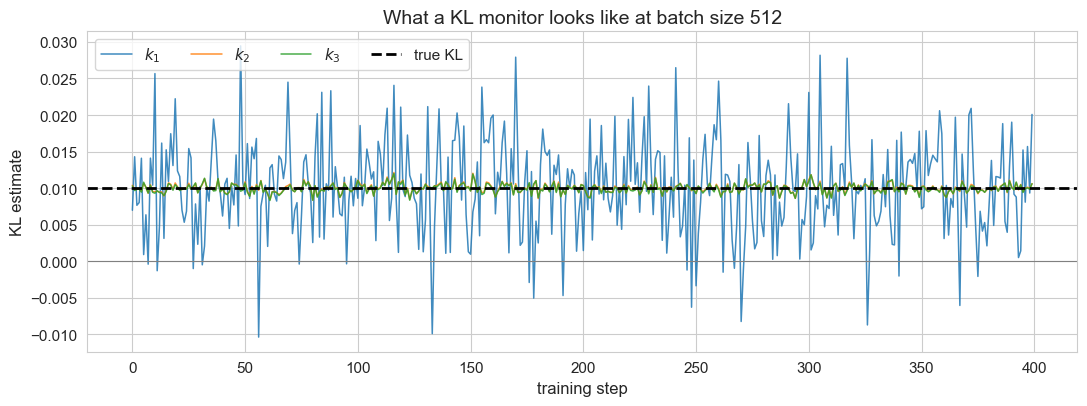


k1 spends a large fraction of steps BELOW ZERO -- an impossible value for a
divergence. As a diagnostic it is unreadable; as a penalty term it is harmful.
k3 tracks the true value closely and never goes negative.


In [21]:
# Simulate an RLHF-style KL monitor: small true KL, modest batch, many steps.
true_small = 0.01
mu = np.sqrt(2*true_small)        # KL = mu^2/2 for unit-variance Gaussians
pd, qd = stats.norm(mu, 1), stats.norm(0, 1)
g = np.random.default_rng(99)

batch, steps = 512, 400
tracks = {"k1": [], "k2": [], "k3": []}
for _ in range(steps):
    x = qd.rvs(size=batch, random_state=g)
    lr = pd.logpdf(x) - qd.logpdf(x); r = np.exp(lr)
    tracks["k1"].append((-lr).mean())
    tracks["k2"].append((0.5*lr**2).mean())
    tracks["k3"].append(((r-1)-lr).mean())

print(f"true KL = {true_small};  batch = {batch};  {steps} monitoring steps\n")
print(f"{'':>5}{'mean':>11}{'std':>11}{'% of steps negative':>22}")
print("-" * 50)
for k, v in tracks.items():
    v = np.array(v)
    print(f"{k:>5}{v.mean():>11.5f}{v.std():>11.5f}{(v < 0).mean():>21.1%}")

fig, ax = plt.subplots(figsize=(11, 4.2))
for k, c in [("k1",'C0'), ("k2",'C1'), ("k3",'C2')]:
    ax.plot(tracks[k], color=c, lw=1.1, alpha=.85, label=f"$k_{k[1]}$")
ax.axhline(true_small, color='k', lw=2, ls='--', label='true KL')
ax.axhline(0, color='grey', lw=.8)
ax.set_xlabel("training step"); ax.set_ylabel("KL estimate")
ax.set_title(f"What a KL monitor looks like at batch size {batch}")
ax.legend(ncol=4); plt.tight_layout(); plt.show()

print("\nk1 spends a large fraction of steps BELOW ZERO -- an impossible value for a")
print("divergence. As a diagnostic it is unreadable; as a penalty term it is harmful.")
print("k3 tracks the true value closely and never goes negative.")

---
## 14. Summary

**The setup.** You can sample from $q$ and evaluate $\log p$, $\log q$. You want
$\mathrm{KL}[q,p]$. Write $r = p(x)/q(x)$, so $\log r = \log p(x) - \log q(x)$.

| estimator | formula | unbiased | non-negative | variance |
|---|---|---|---|---|
| $k_1$ | $-\log r$ | ✅ | ❌ | ❌ high |
| $k_2$ | $\tfrac12(\log r)^2$ | ❌ small bias | ✅ | ✅ low |
| $k_3$ | $(r-1) - \log r$ | ✅ | ✅ | ✅ low |

**Use $k_3$.** It has no downside relative to the other two.

**The three ideas, in one line each**

1. **$k_1$ is noisy because it is negative half the time**, while the thing it estimates is
   always positive (§1, §3).
2. **$k_2$ is nearly unbiased because every $f$-divergence with $f''(1)=1$ agrees with KL to
   second order** — so for $p \approx q$ it is measuring almost the same thing (§6).
3. **$k_3$ = $k_1$ + a control variate.** $r-1$ has mean exactly zero, so adding it cannot
   introduce bias; choosing the coefficient $\lambda = 1$ makes the result non-negative,
   because $\log x \le x-1$ (§7, §8).

**The general recipe.** For any $f$-divergence, $f(r) - f'(1)(r-1)$ is an unbiased,
non-negative estimator from samples of $q$. It is the gap between a convex function and its
tangent — a Bregman divergence (§9).

**The trap.** $\mathrm{KL}[a,b]$ averages over $a$. With samples from $q$ and $r = p/q$:
$k_3$ gives $\mathrm{KL}[q,p]$, and $r\log r - (r-1)$ gives $\mathrm{KL}[p,q]$. The post's
prose and its code assign $p$ and $q$ oppositely; it is invisible for equal-variance Gaussians
and wrong by 4× as soon as the variances differ (§12).

---

### Source and further reading

- John Schulman, [*Approximating KL Divergence*](http://joschu.net/blog/kl-approx.html), 2020
  — the original, worth reading directly now that the pieces are familiar.
- Notebook 02 in this series — entropy, KL and mutual information from scratch.
- Owen, *Monte Carlo theory, methods and examples*, ch. 8 — control variates in general.
- Schulman et al., [*Proximal Policy Optimization*](https://arxiv.org/abs/1707.06347) — where
  the KL constraint comes from.
- Amari, *Information Geometry and Its Applications* — the $f$-divergence / Fisher
  information story behind §6.